## Title: DSC355 USL Championship 2025 EDA
# Author: James Sneddon
# Date: 29 March 2026
# Modified By: James Sneddon
# Description: EDA of USL Championship 2025 match-level team statistics across 24 teams

In [1]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

In [2]:
df = pd.read_csv("data/USL_Championship_2025_Team_Stats.csv")

In [3]:
# convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
df.head()

,Team,Date,Match,Competition,Duration,Scheme,Goals,xG,Shots,Shots on target,...,Throw ins,Accurate throw ins,Throw in accuracy %,Goal kicks,Match tempo,Average passes per possession,Long pass %,Average shot distance,Average pass length,PPDA
0,Birmingham Legion,2025-10-25,Charleston Battery - Birmingham Legion 2:1,United States. USL Championship,98,5-3-2 (51.4%),1,0.22,3.0,3.0,...,20.0,19.0,95.00,11.0,14.54,3.11,16.97,26.59,19.27,28.92
1,Birmingham Legion,2025-10-19,Birmingham Legion - Miami 2:3,United States. USL Championship,105,3-5-2 (83.46%),2,2.71,14.0,4.0,...,25.0,23.0,92.00,8.0,16.30,4.89,7.49,17.63,19.96,8.56
2,Birmingham Legion,2025-10-04,Loudoun United - Birmingham Legion 0:1,United States. USL Championship,100,3-5-2 (100.0%),1,1.19,6.0,2.0,...,21.0,16.0,76.19,9.0,14.71,2.89,21.91,19.80,22.49,17.95
3,Birmingham Legion,2025-10-02,Birmingham Legion - North Carolina FC 1:1,United States. USL Championship,101,5-3-2 (100.0%),1,1.00,11.0,3.0,...,28.0,26.0,92.86,5.0,16.61,5.91,7.18,19.98,18.30,13.11
4,Birmingham Legion,2025-09-28,San Antonio - Birmingham Legion 0:0,United States. USL Championship,105,5-3-2 (80.27%),0,0.25,6.0,2.0,...,13.0,11.0,84.62,12.0,15.77,3.07,14.18,19.90,20.88,12.44


In [5]:
df.describe()

,Date,Duration,Goals,xG,Shots,Shots on target,Shots on target %,Passes,Accurate passes,Pass accuracy %,...,Throw ins,Accurate throw ins,Throw in accuracy %,Goal kicks,Match tempo,Average passes per possession,Long pass %,Average shot distance,Average pass length,PPDA
count,746,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,...,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,2025-07-13 00:57:54.530830848,100.026810,1.312332,1.250469,10.455764,3.672922,35.969960,386.813673,317.107239,81.087560,...,19.915550,17.441019,87.816595,7.981233,15.803847,3.896233,12.915456,18.326783,20.409155,11.094263
min,2025-03-09 00:00:00,92.000000,0.000000,0.010000,1.000000,0.000000,0.000000,148.000000,93.000000,62.390000,...,5.000000,4.000000,52.940000,0.000000,10.270000,1.640000,3.910000,8.740000,15.840000,3.810000
25%,2025-05-11 00:00:00,97.000000,0.000000,0.690000,8.000000,2.000000,25.000000,320.000000,250.250000,77.842500,...,15.250000,13.000000,81.480000,6.000000,14.947500,3.160000,9.875000,16.317500,19.450000,8.100000
50%,2025-07-17 00:00:00,99.000000,1.000000,1.120000,10.000000,3.000000,33.330000,379.500000,309.000000,81.705000,...,19.000000,17.000000,88.890000,8.000000,15.915000,3.795000,12.410000,18.125000,20.295000,10.455000
75%,2025-09-14 00:00:00,101.000000,2.000000,1.630000,13.000000,5.000000,47.637500,445.750000,377.000000,85.257500,...,23.000000,21.000000,94.740000,10.000000,16.610000,4.520000,15.440000,20.122500,21.315000,12.910000
max,2025-11-22 00:00:00,194.000000,6.000000,5.850000,27.000000,12.000000,100.000000,652.000000,580.000000,91.480000,...,39.000000,35.000000,100.000000,22.000000,19.950000,8.160000,28.500000,32.140000,25.770000,44.860000
std,NaN,7.464948,1.155220,0.736447,4.242805,2.084842,17.348844,91.923130,89.983231,5.408572,...,5.993921,5.392750,9.149441,3.224016,1.235583,1.018834,4.246931,3.156976,1.461959,4.375193


In [6]:
# matches and date range for each team with typical summary statistic means attached
summary = df.groupby('Team').agg(
    Matches=('Date', 'count'),
    First_Match=('Date', 'min'),
    Last_Match=('Date', 'max'),
    Avg_Goals=('Goals', 'mean'),
    Avg_xG=('xG', 'mean'),
    Avg_Conceded=('Conceded goals', 'mean'),
    Avg_Possession=('Possession %', 'mean'),
    Avg_Passes=('Passes', 'mean'),
    Avg_Pass_Acc=('Pass accuracy %', 'mean'),
    Avg_PPDA=('PPDA', 'mean')
).round(2)
summary

,Matches,First_Match,Last_Match,Avg_Goals,Avg_xG,Avg_Conceded,Avg_Possession,Avg_Passes,Avg_Pass_Acc,Avg_PPDA
Team,,,,,,,,,,
Birmingham Legion,30,2025-03-09,2025-10-25,1.20,1.16,1.67,49.44,386.07,81.36,13.43
Charleston Battery,30,2025-03-09,2025-11-02,1.90,1.60,1.07,59.61,494.37,85.65,9.57
Colorado Springs,30,2025-03-09,2025-11-02,1.17,1.24,1.43,51.61,375.77,81.78,11.26
Detroit City,32,2025-03-09,2025-11-09,1.06,0.91,1.09,52.57,386.28,80.60,10.21
El Paso Locomotive,31,2025-03-09,2025-11-02,1.52,1.27,1.48,53.25,419.29,84.44,12.30
FC Tulsa,34,2025-03-09,2025-11-22,1.62,1.62,0.88,45.49,285.29,73.53,9.31
Hartford Athletic,30,2025-03-09,2025-11-01,1.47,1.48,1.20,45.20,327.33,76.99,10.83
Indy Eleven,30,2025-03-16,2025-10-26,1.47,1.18,1.73,43.00,322.90,75.88,12.31
Las Vegas Lights,30,2025-03-09,2025-10-26,0.77,0.82,1.67,47.75,365.23,82.42,12.65


In [16]:
# xG vs actual goals: how well did each team finish?
xg_goals = df.groupby('Team')[['Goals', 'xG']].mean().round(3)
xg_goals['xG_diff'] = (xg_goals['Goals'] - xg_goals['xG']).round(3)
xg_goals.sort_values('xG_diff', ascending=False)

,Goals,xG,xG_diff
Team,,,
Phoenix Rising,1.531,1.204,0.327
Oakland Roots,1.400,1.094,0.306
Charleston Battery,1.900,1.598,0.302
Tampa Bay Rowdies,1.433,1.140,0.293
Indy Eleven,1.467,1.185,0.282
New Mexico United,1.531,1.263,0.268
El Paso Locomotive,1.516,1.269,0.247
Louisville City,1.806,1.582,0.224
North Carolina FC,1.281,1.079,0.202


In [8]:
# goal difference per match (goals scored vs conceded per match)
gd = df.groupby('Team')[['Goals', 'Conceded goals']].mean().round(3)
gd['Goal_Diff'] = (gd['Goals'] - gd['Conceded goals']).round(3)
gd.sort_values('Goal_Diff', ascending=False)

,Goals,Conceded goals,Goal_Diff
Team,,,
Louisville City,1.806,0.645,1.161
Charleston Battery,1.900,1.067,0.833
FC Tulsa,1.618,0.882,0.736
Sacramento Republic,1.419,0.871,0.548
Hartford Athletic,1.467,1.200,0.267
New Mexico United,1.531,1.281,0.250
Pittsburgh Riverhounds,0.971,0.824,0.147
El Paso Locomotive,1.516,1.484,0.032
Rhode Island,0.939,0.909,0.030


In [9]:
# correlation between key attacking metrics and goals scored
attack_cols = ['Goals', 'xG', 'Shots', 'Shots on target', 'Positional attacks',
               'Counterattacks', 'Touches in penalty area', 'Possession %',
               'Passes to final third', 'Progressive passes']
df[attack_cols].corr()[['Goals']].sort_values('Goals', ascending=False)

,Goals
Goals,1.000000
Shots on target,0.568027
xG,0.452862
Shots,0.224237
Touches in penalty area,0.171571
Counterattacks,0.076673
Positional attacks,0.008700
Passes to final third,-0.098796
Progressive passes,-0.099725
Possession %,-0.141153


In [10]:
profile = ProfileReport(df, title="USL Championship 2025 Team Stats", explorative=True)

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

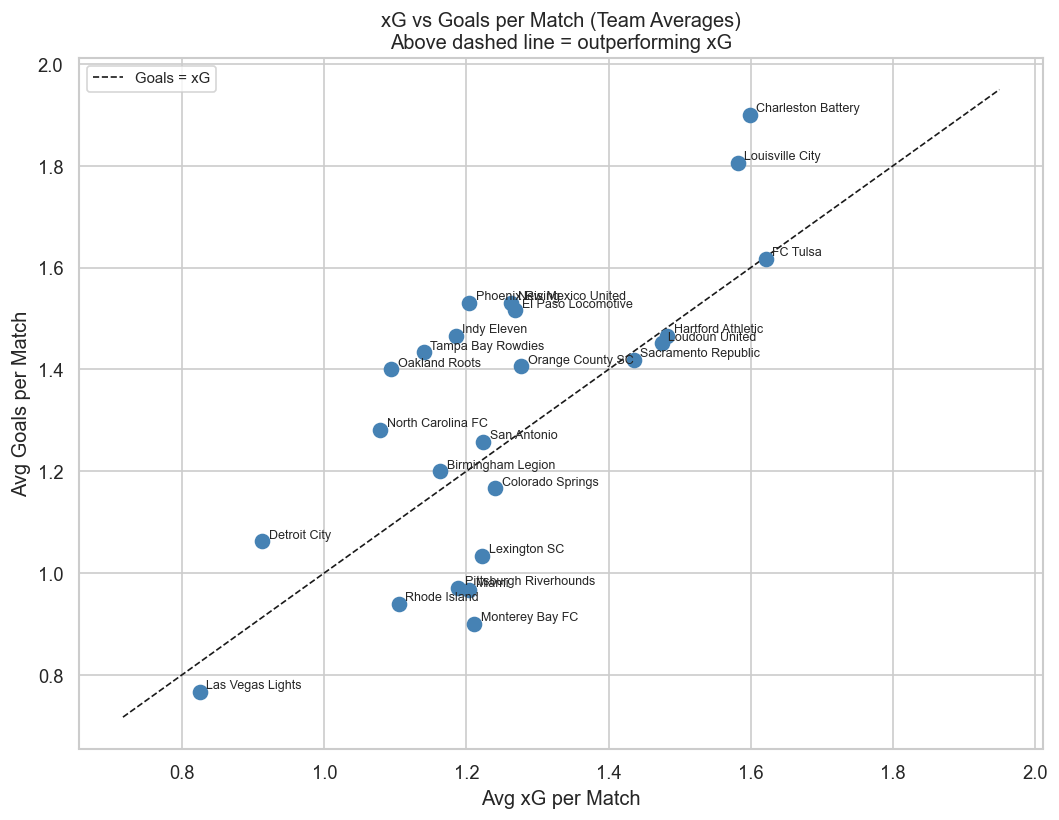

In [18]:
#xG vs Goals (team averages) — who finishes above/below expectation?
team_avg = df.groupby('Team')[['Goals', 'xG']].mean()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(team_avg['xG'], team_avg['Goals'], s=70, color='steelblue', zorder=3)

lim = [team_avg[['Goals', 'xG']].min().min() - 0.05,
       team_avg[['Goals', 'xG']].max().max() + 0.05]
ax.plot(lim, lim, 'k--', lw=1, label='Goals = xG')

for team, row in team_avg.iterrows():
    ax.annotate(team, (row['xG'], row['Goals']), fontsize=7.5, xytext=(4, 2), textcoords='offset points')

ax.set(xlabel='Avg xG per Match', ylabel='Avg Goals per Match',
       title='xG vs Goals per Match (Team Averages)\nAbove dashed line = outperforming xG')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

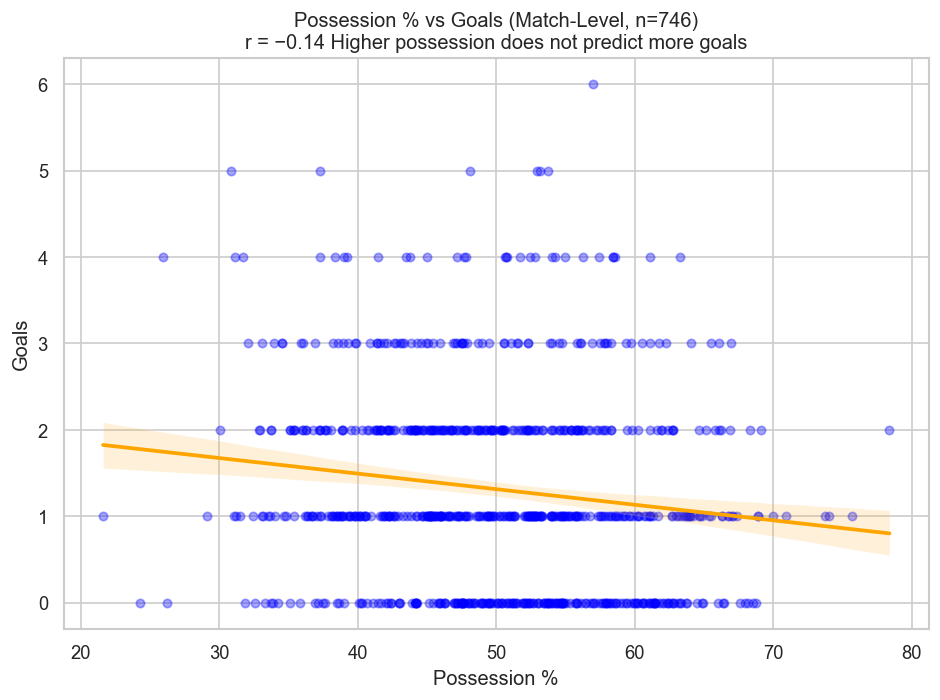

In [24]:
#Possession % vs Goals (match-level) — possession ≠ goals (r=-0.14)
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df, x='Possession %', y='Goals', ax=ax,
            scatter_kws={'alpha': 0.35, 's': 25, 'color': 'blue'},
            line_kws={'color': 'orange'})

ax.set_xlabel('Possession %')
ax.set_ylabel('Goals')
ax.set_title('Possession % vs Goals (Match-Level, n=746)\nr = −0.14 Higher possession does not predict more goals')
plt.tight_layout()
plt.show()

# Dataset: 746 match observations across all 2025 USL Championship teams, 109 columns
# Date range spans the 2025 season. All numeric columns are clean with no missing values.
#
# observations:
# - Goals and xG are closely correlated — shots on target is the strongest predictor of goals
# - Possession % shows moderate correlation with pass volume but not directly with goals
# - PPDA (passes allowed per defensive action) varies significantly by team: lower = more pressing
# - xG_diff (Goals - xG) identifies over/underperforming teams relative to shot quality
# - Match duration varies (90–120+ min) due to extra time in playoff matches (consider eliminating playoff matches from dataset) 
# - Consider adding points (win - 3, draw - 1, loss - 0)
#
# Categorical columns: Team, Match, Competition, Scheme (formation)
# Date converted to datetime for time-series analysis